<a href="https://colab.research.google.com/github/Nkengfack/Bank_marketing_ml_Classifications/blob/main/bank_marketing_ML_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##A Comparative Performance Analysis of Machine Learning Models for the Prediction of Bank Term Deposit Subscriptions

## 1. Setup

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

from warnings import filterwarnings
filterwarnings('ignore')

sns.set_style('white')
DROP_DURATION = True  # duration leaks the target; flip to False to keep it

## 2. Load the data

In [ ]:
FILE_URL = 'https://raw.githubusercontent.com/Nkengfack/Bank_marketing_ml_Classifications/refs/heads/main/bank_marketing_dataset.csv'

marketing = pd.read_csv(FILE_URL, sep=';')

# Replace dots in column names so they play nicely with the rest of the code
marketing.columns = marketing.columns.str.replace('.', '_', regex=False)

# Readable labels for plot titles
feature_labels = {
    'age': 'Age',
    'job': 'Job',
    'marital': 'Marital Status',
    'education': 'Education',
    'default': 'Credit in Default',
    'housing': 'Housing Loan',
    'loan': 'Personal Loan',
    'contact': 'Contact Type',
    'month': 'Last Contact Month',
    'day_of_week': 'Last Contact Day',
    'duration': 'Call Duration (s)',
    'campaign': 'Contacts This Campaign',
    'pdays': 'Days Since Last Contact',
    'previous': 'Previous Contacts',
    'poutcome': 'Previous Outcome',
    'emp_var_rate': 'Employment Variation Rate',
    'cons_price_idx': 'Consumer Price Index',
    'cons_conf_idx': 'Consumer Confidence Index',
    'euribor3m': 'Euribor 3-Month Rate',
    'nr_employed': 'Number of Employees',
    'y': 'Subscribed'
}

marketing.sample(10, random_state=42)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
32884,57,technician,married,high.school,no,no,yes,cellular,may,mon,...,1,999,1,failure,-1.8,92.893,-46.2,1.299,5099.1,no
3169,55,unknown,married,unknown,unknown,yes,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no
32206,33,blue-collar,married,basic.9y,no,no,no,cellular,may,fri,...,1,999,1,failure,-1.8,92.893,-46.2,1.313,5099.1,no
9403,36,admin.,married,high.school,no,no,no,telephone,jun,fri,...,4,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1,no
14020,27,housemaid,married,high.school,no,yes,no,cellular,jul,fri,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
17201,58,retired,married,professional.course,no,yes,yes,cellular,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
879,48,services,married,high.school,unknown,yes,no,telephone,may,wed,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
23757,51,admin.,divorced,university.degree,unknown,yes,no,cellular,aug,thu,...,7,999,0,nonexistent,1.4,93.444,-36.1,4.962,5228.1,no
10821,24,entrepreneur,married,university.degree,no,yes,yes,telephone,jun,wed,...,4,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
14355,36,technician,divorced,professional.course,no,yes,yes,cellular,jul,mon,...,4,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no


In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [ ]:
marketing.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp_var_rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons_price_idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons_conf_idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr_employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


## 3. Cleaning

In [ ]:
duplicates = marketing.duplicated().sum()
marketing.drop_duplicates(keep='first', ignore_index=True, inplace=True)

print(f'Duplicate rows removed: {duplicates}')
print(f'Rows remaining: {len(marketing):,}')

Duplicate rows removed: 12
Rows remaining: 41,176


In [ ]:
# No NaN values in this dataset, but several categoricals use the string 'unknown'
print('NaN values per column:')
print(marketing.isnull().sum().sum(), 'in total\n')

unknown_counts = (marketing == 'unknown').sum()
print("Rows with the value 'unknown':")
print(unknown_counts[unknown_counts > 0])
print(f"\n{unknown_counts.sum():,} in total")

NaN values per column:
0 in total

Rows with the value 'unknown':
job           330
marital        80
education    1730
default      8596
housing       990
loan          990
dtype: int64

12,716 in total


`unknown` is kept as its own category rather than imputed away. The absence of information (for example a client refusing to state their job) can itself be predictive, and one-hot encoding handles it without any guesswork.

In [ ]:
numerical_cols = marketing.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = marketing.select_dtypes(include='object').drop(columns='y').columns.tolist()

for col in categorical_cols:
    print(f'{col}: {sorted(marketing[col].unique())}')

job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
marital: ['divorced', 'married', 'single', 'unknown']
education: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']
default: ['no', 'unknown', 'yes']
housing: ['no', 'unknown', 'yes']
loan: ['no', 'unknown', 'yes']
contact: ['cellular', 'telephone']
month: ['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
day_of_week: ['fri', 'mon', 'thu', 'tue', 'wed']
poutcome: ['failure', 'nonexistent', 'success']


## 4. Exploratory data analysis

### 4.1 Target distribution and class imbalance

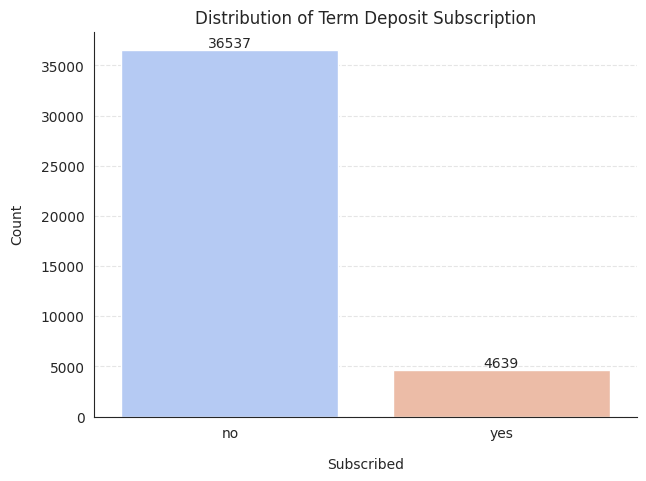

y
no     0.887
yes    0.113
Name: proportion, dtype: float64

Imbalance ratio (no : yes) = 7.9 : 1
The minority class is small, so SMOTE oversampling is applied on the training folds inside the pipeline.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
sns.countplot(data=marketing, x='y', hue='y', palette='coolwarm', legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.title('Distribution of Term Deposit Subscription')
plt.xlabel('Subscribed', labelpad=12)
plt.ylabel('Count', labelpad=12)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

class_share = marketing['y'].value_counts(normalize=True).round(3)
ratio = marketing['y'].value_counts()
print(class_share)
print(f"\nImbalance ratio (no : yes) = {ratio['no'] / ratio['yes']:.1f} : 1")
print('The minority class is small, so SMOTE oversampling is applied on the training folds inside the pipeline.')

### 4.2 Numerical distributions

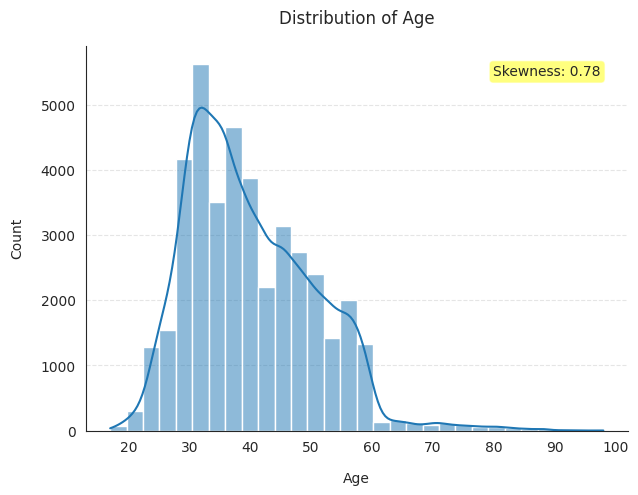

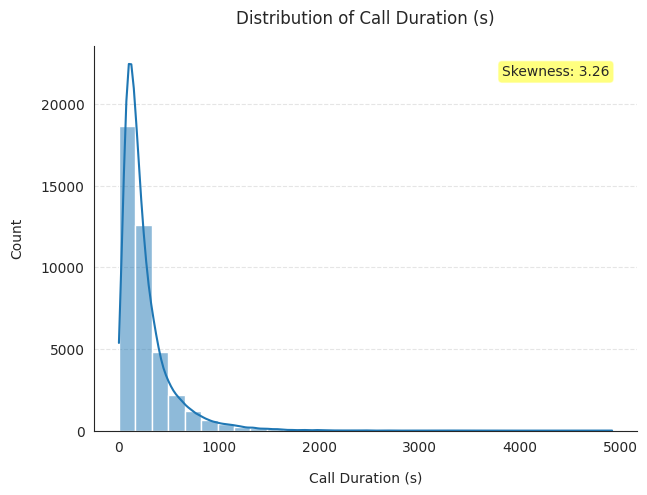

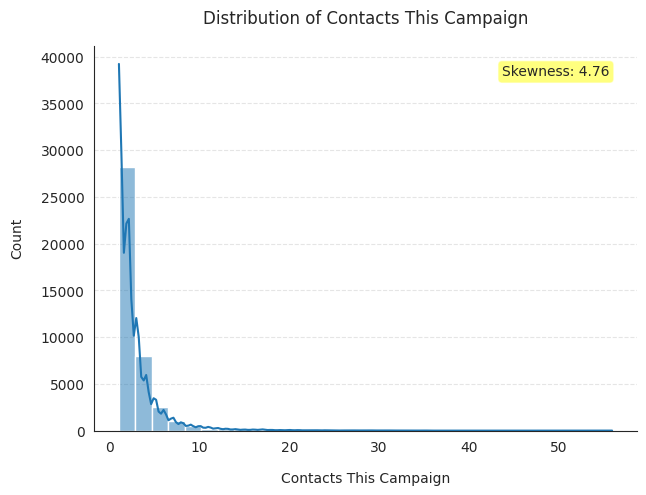

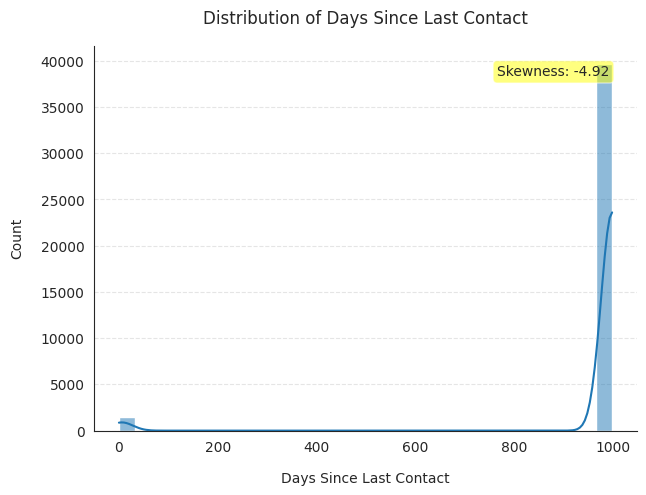

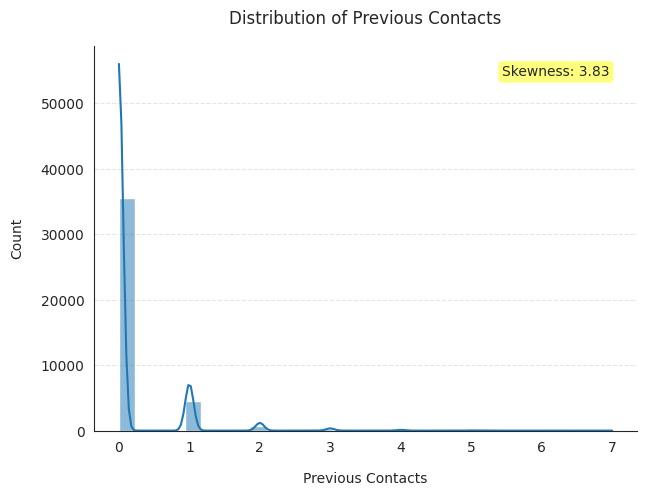

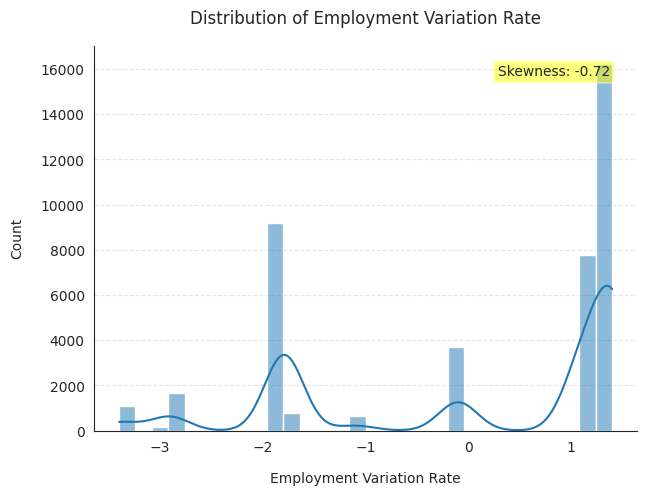

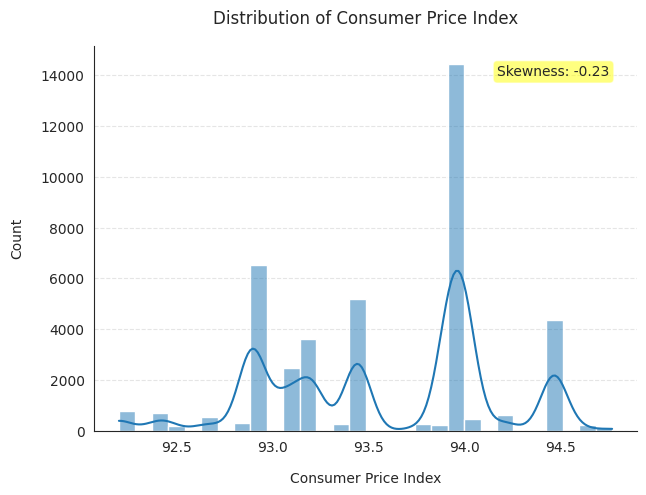

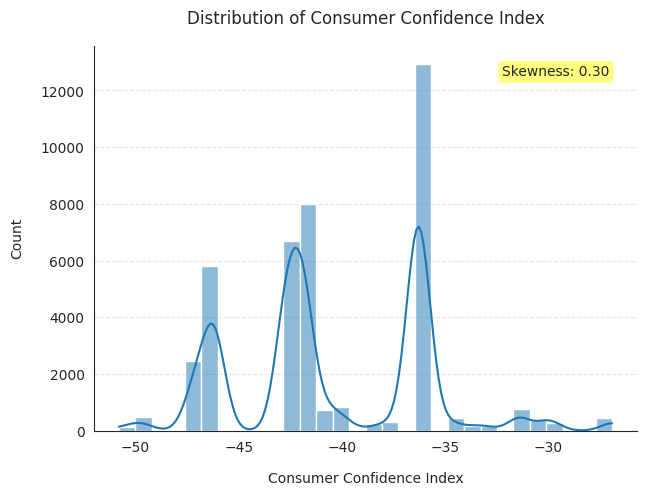

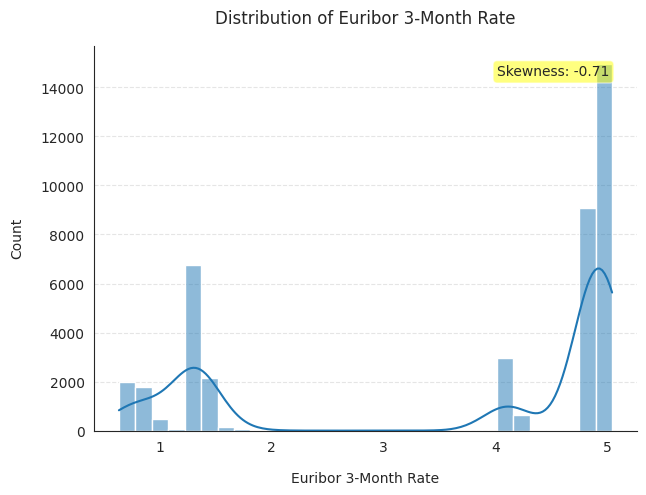

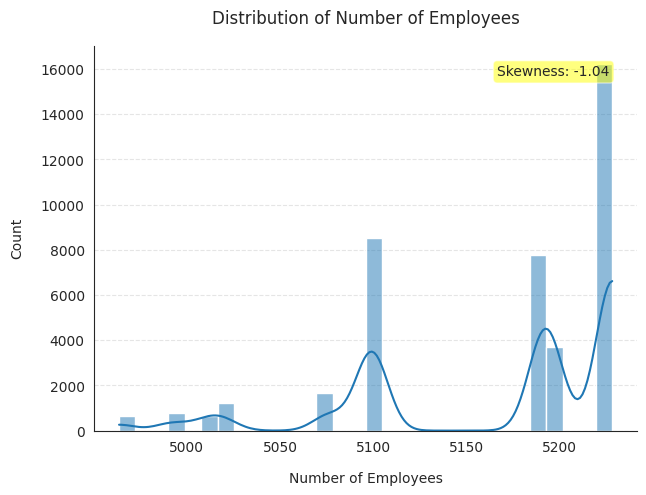

In [ ]:
for col in numerical_cols:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.histplot(marketing[col], kde=True, bins=30)
    plt.title(f'Distribution of {feature_labels.get(col, col)}', pad=16)
    plt.text(
        0.95, 0.95, f'Skewness: {marketing[col].skew():.2f}', transform=ax.transAxes,
        horizontalalignment='right', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
    )
    plt.xlabel(feature_labels.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'Distribution of {col}.png', dpi=300)
    plt.show()
    print('\n')

### 4.3 Categorical distributions

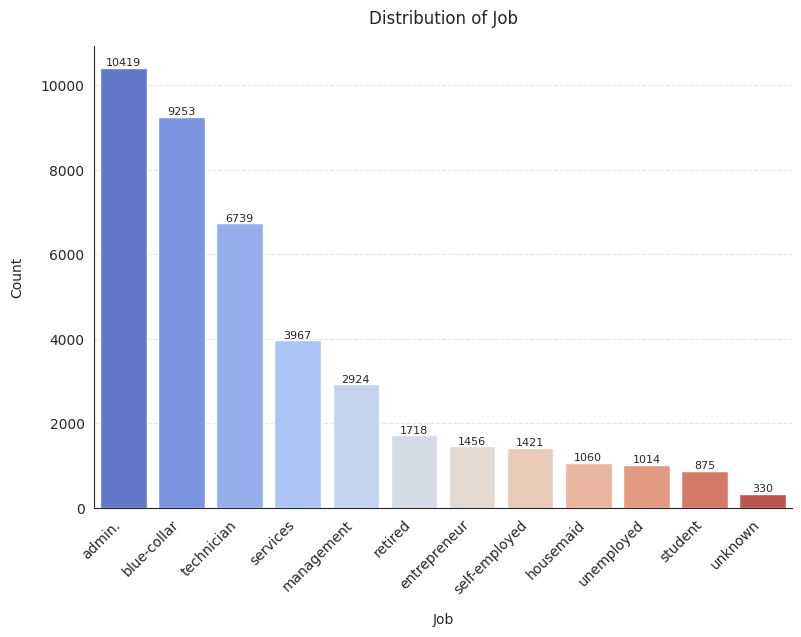

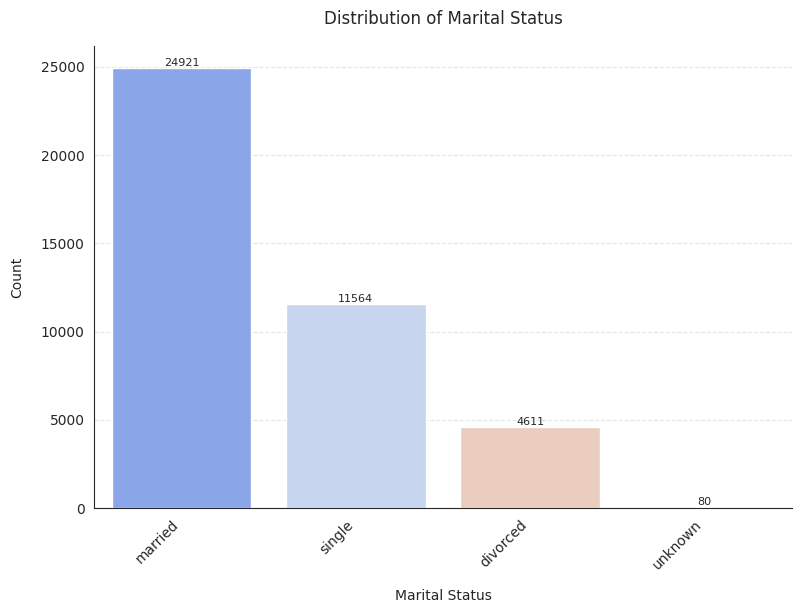

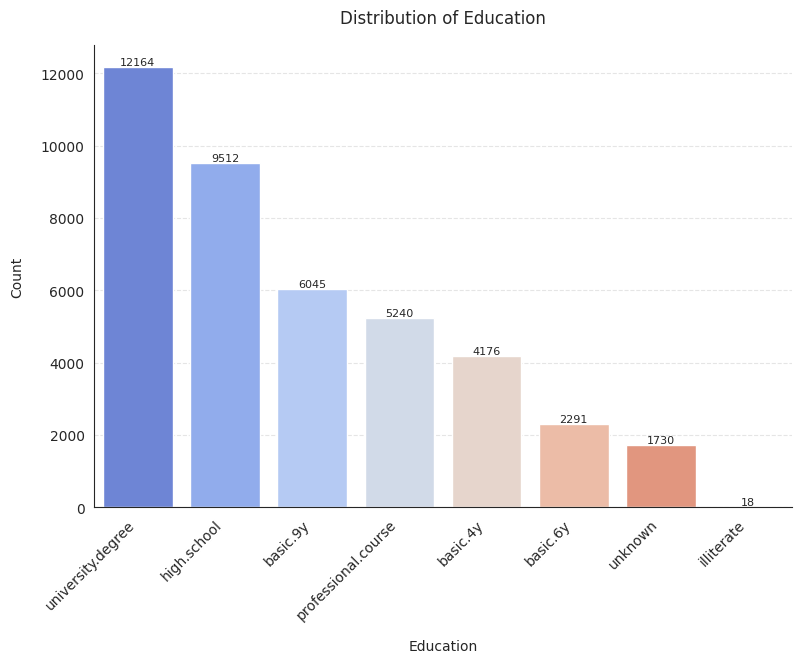

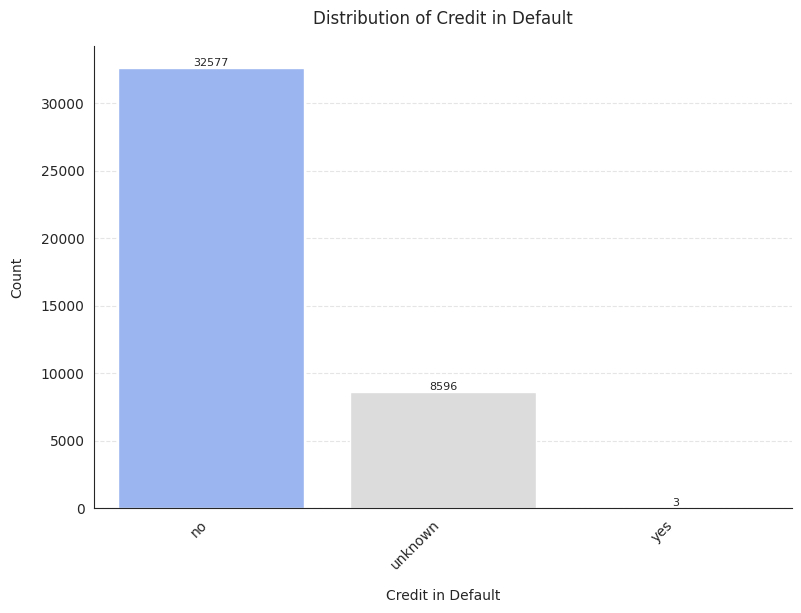

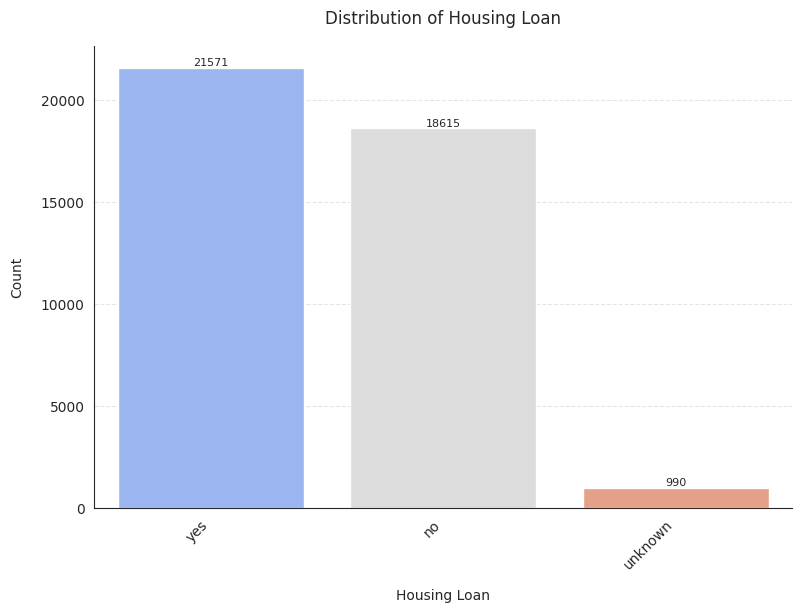

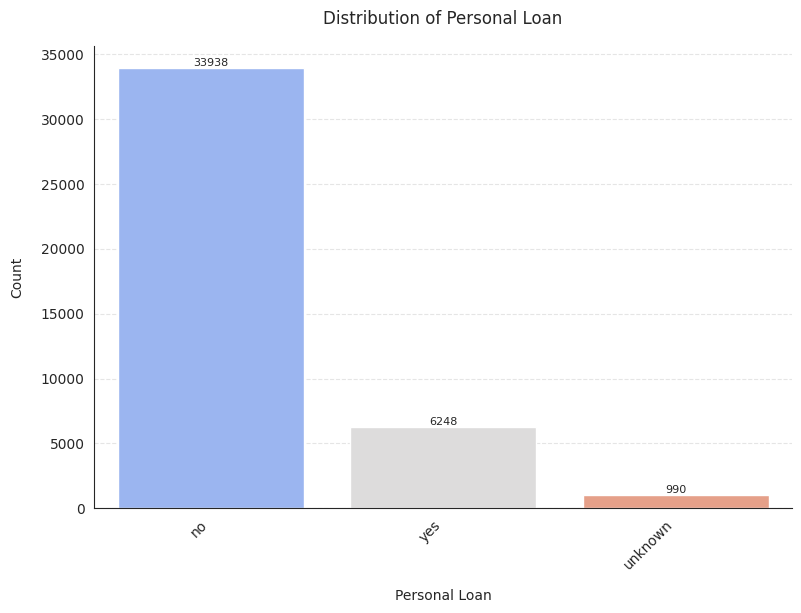

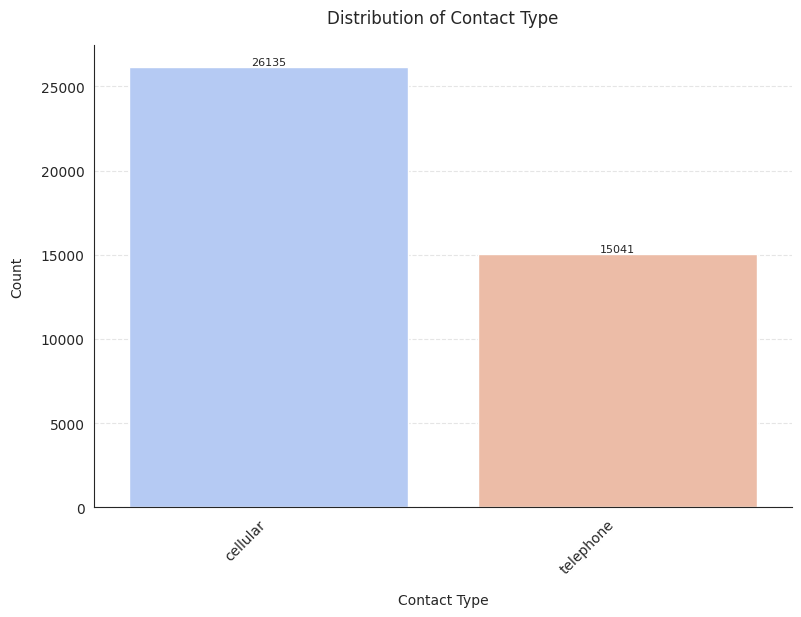

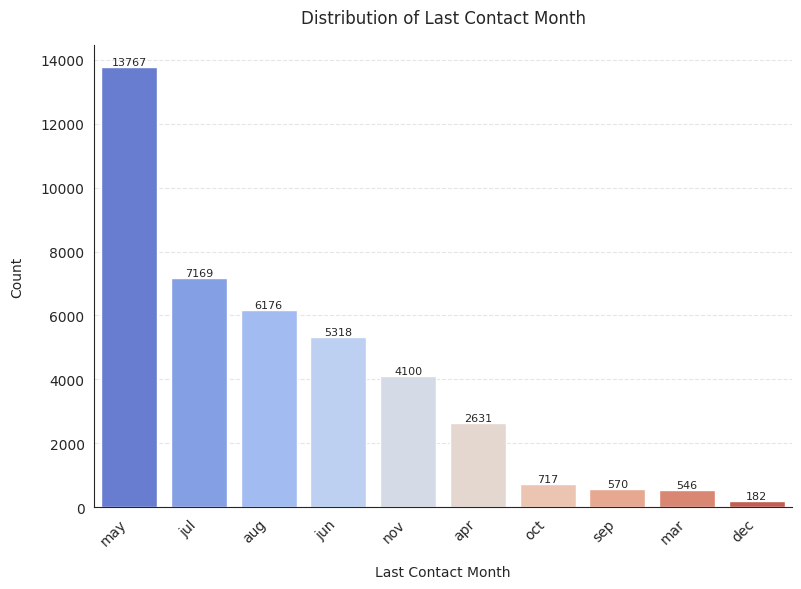

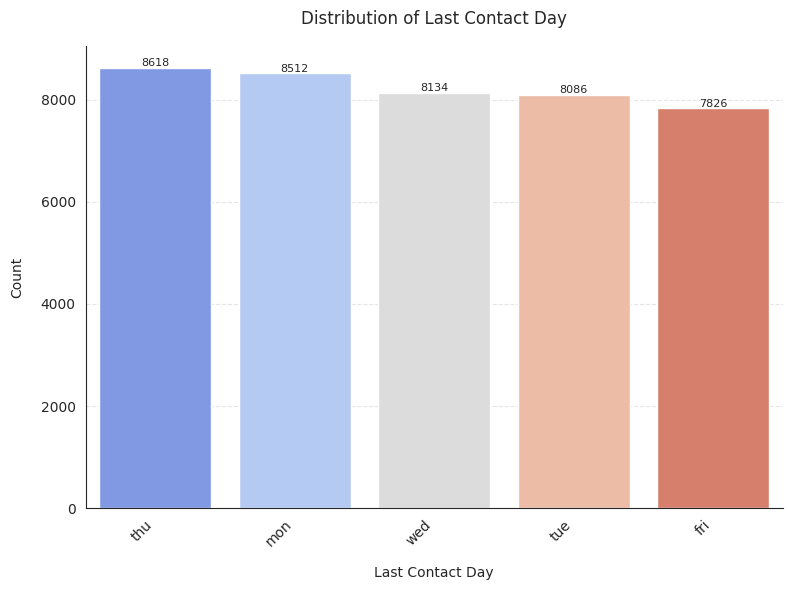

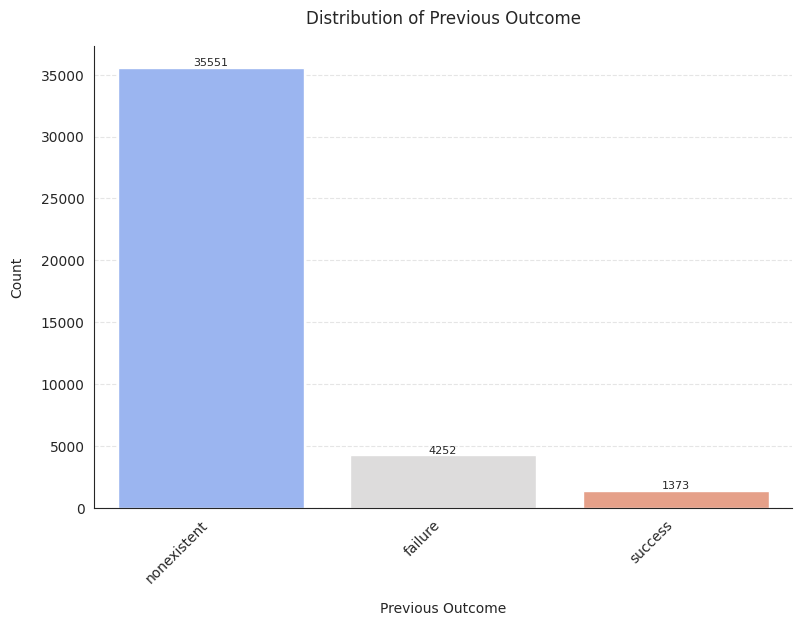

In [ ]:
for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
    order = marketing[col].value_counts().index
    sns.countplot(data=marketing, x=col, palette='coolwarm', ax=ax, order=order)
    plt.title(f'Distribution of {feature_labels.get(col, col)}', pad=16)
    plt.xlabel(feature_labels.get(col, col), labelpad=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count', labelpad=12)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'Distribution of {col}.png', dpi=300)
    plt.show()
    print('\n')

### 4.4 Subscription rate by category

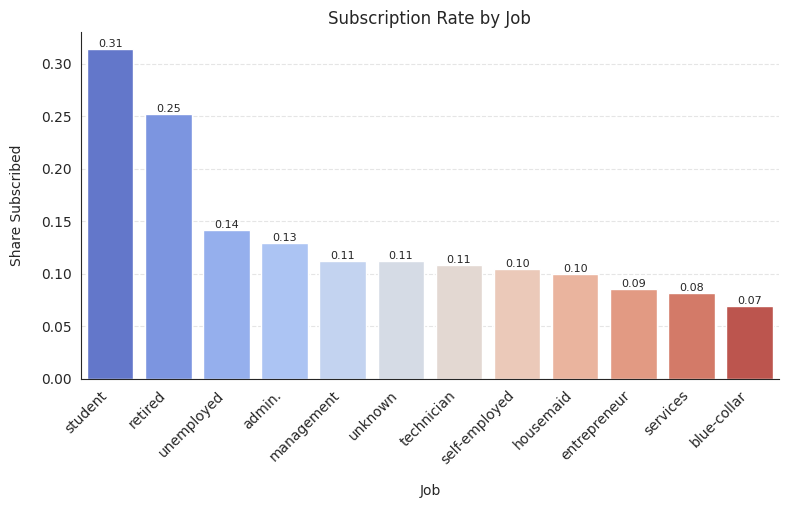

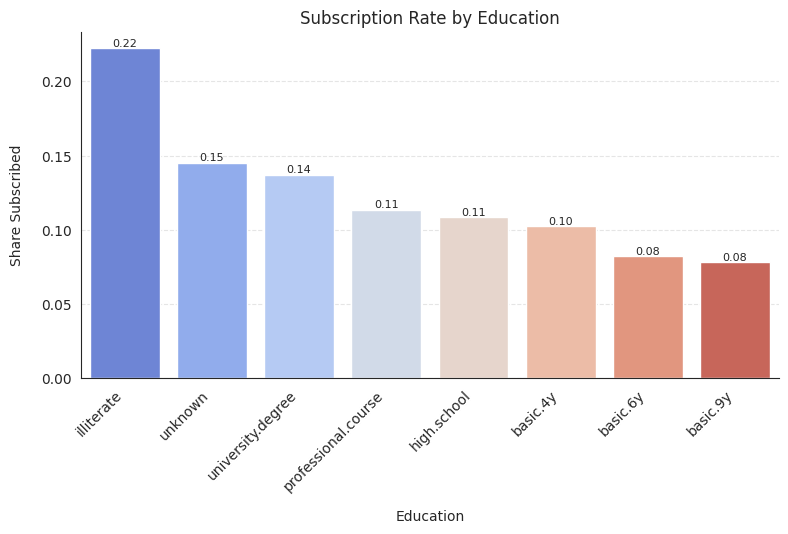

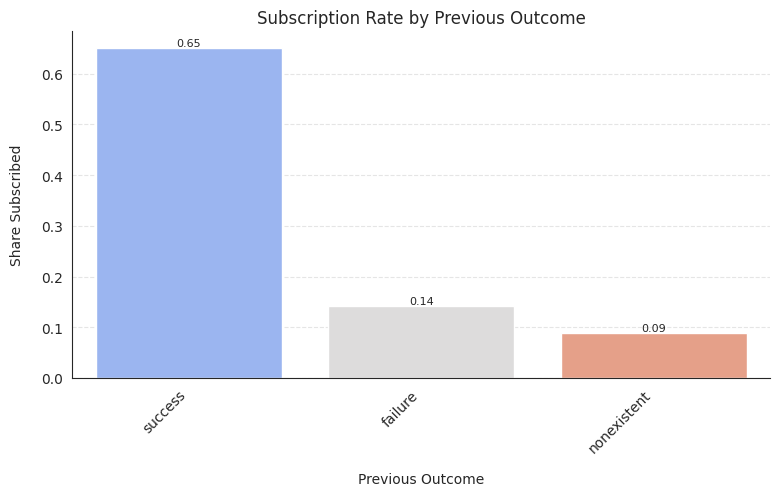

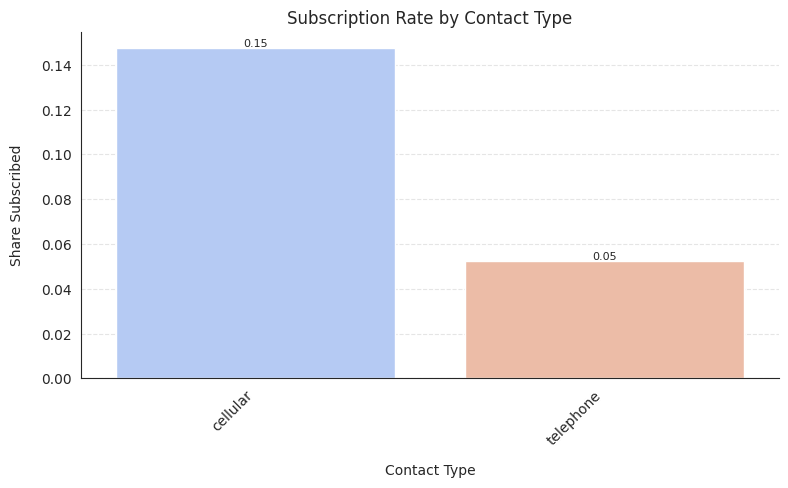

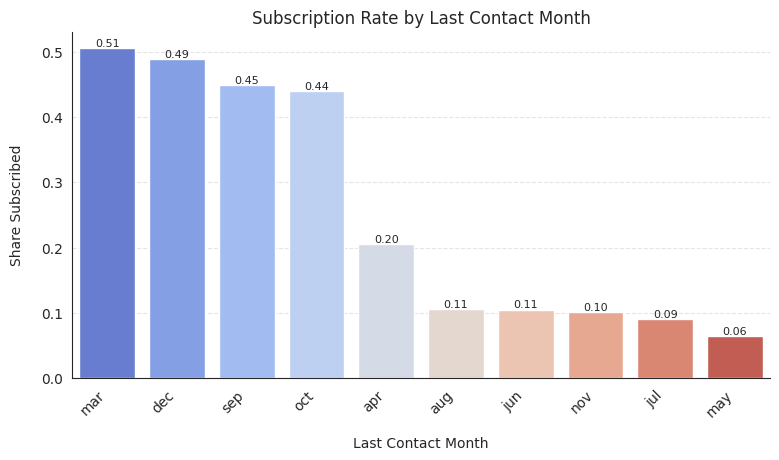

In [ ]:
# Which categories convert best? More informative than raw counts on an imbalanced target.
for col in ['job', 'education', 'poutcome', 'contact', 'month']:
    rate = (marketing.groupby(col)['y']
                .apply(lambda s: (s == 'yes').mean())
                .sort_values(ascending=False))
    fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
                palette='coolwarm', legend=False, ax=ax)
    ax.set_title(f'Subscription Rate by {feature_labels[col]}')
    ax.set_ylabel('Share Subscribed', labelpad=12)
    ax.set_xlabel(feature_labels[col], labelpad=12)
    plt.xticks(rotation=45, ha='right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=8)
    sns.despine(top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'rate_by_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('\n')

### 4.5 Correlation heatmap

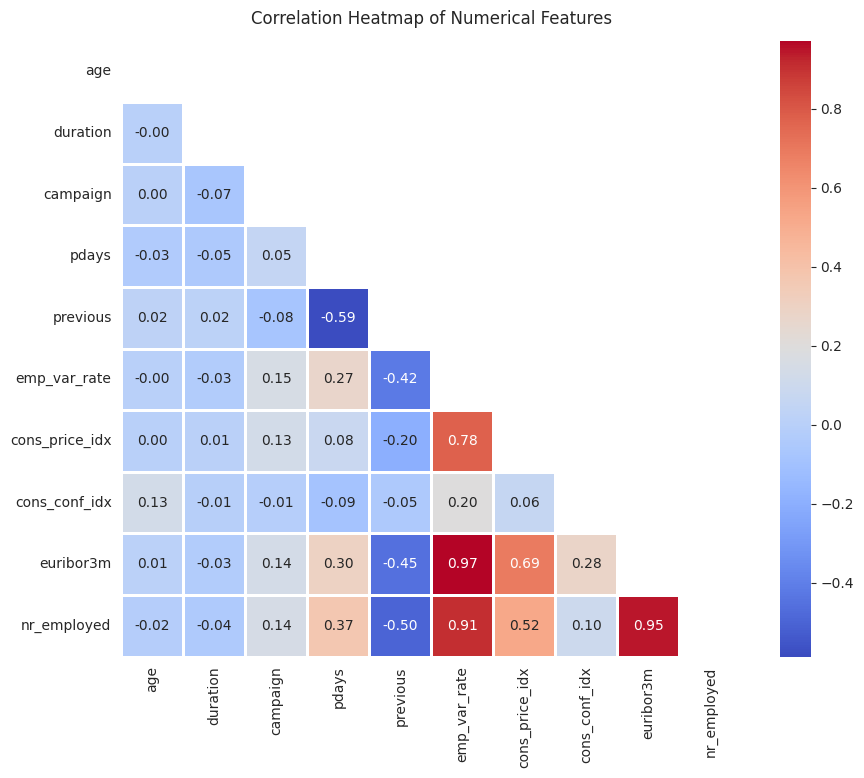

emp_var_rate, euribor3m and nr_employed are highly correlated (all track the economic cycle). Tree models cope with this; for logistic regression the coefficients on these columns should be read with care.


In [ ]:
corr = marketing[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.subplots(figsize=(10, 8), dpi=100)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=1, cbar=True)
plt.title('Correlation Heatmap of Numerical Features', pad=12)
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('emp_var_rate, euribor3m and nr_employed are highly correlated (all track the '
      'economic cycle). Tree models cope with this; for logistic regression the '
      'coefficients on these columns should be read with care.')

In [ ]:

# We drop redundant economic indicators to reduce multicollinearity
redundant = ['emp_var_rate', 'nr_employed']
marketing = marketing.drop(columns=redundant, errors='ignore')

print(f'Dropped: {redundant}')
print(f'Shape now: {marketing.shape}')
print('Numeric columns remaining:',
      marketing.select_dtypes(include='number').columns.tolist())

Dropped: ['emp_var_rate', 'nr_employed']
Shape now: (41176, 19)
Numeric columns remaining: ['age', 'duration', 'campaign', 'pdays', 'previous', 'cons_price_idx', 'cons_conf_idx', 'euribor3m']


## 5. Feature engineering

Four changes:

1. `pdays` uses 999 as a sentinel for "never contacted before". It becomes a binary `previously_contacted` flag plus `pdays_clean`, which keeps the true gap for contacted clients and uses -1 for the rest. The -1 matters: mapping never-contacted to 0 would collide with clients genuinely contacted zero days ago, which is a real value in this data.
2. `total_contacts` combines contacts in this campaign with contacts in earlier ones.
3. `age_group` is created for EDA. It stays out of the model because raw `age` already carries the signal and the models can learn their own cut points.
4. `campaign` is capped later, after the split, using bounds computed on training data only (section 6).

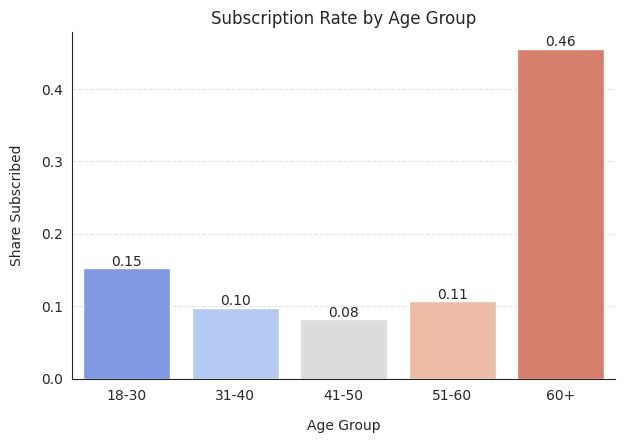

In [ ]:
# 1. pdays sentinel handling: flag plus collision-free gap
marketing['previously_contacted'] = (marketing['pdays'] != 999).astype(int)
marketing['pdays_clean'] = np.where(marketing['pdays'] == 999, -1, marketing['pdays'])

# 2. Total contact pressure across campaigns
marketing['total_contacts'] = marketing['campaign'] + marketing['previous']

# 3. Age groups (EDA only)
age_bins = [17, 30, 40, 50, 60, 100]
age_labels = ['18-30', '31-40', '41-50', '51-60', '60+']
marketing['age_group'] = pd.cut(marketing['age'], bins=age_bins, labels=age_labels)

feature_labels['previously_contacted'] = 'Previously Contacted'
feature_labels['pdays_clean'] = 'Days Since Previous Contact (Adjusted)'
feature_labels['total_contacts'] = 'Total Contacts'
feature_labels['age_group'] = 'Age Group'

# Subscription rate by age group
rate = marketing.groupby('age_group', observed=True)['y'].apply(lambda s: (s == 'yes').mean())
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)
sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
            palette='coolwarm', legend=False, ax=ax)
ax.set_title('Subscription Rate by Age Group')
ax.set_ylabel('Share Subscribed', labelpad=12)
ax.set_xlabel('Age Group', labelpad=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('rate_by_age_group.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.1 Outlier check

Outliers are counted here but no rows are deleted. The long right tails in `campaign` and `total_contacts` are genuine behaviour (some clients really were called 40 times) rather than measurement error, so removing those rows would discard real, informative cases. Instead, `campaign` is capped at a training-derived bound in section 6.1, which limits the leverage of extreme values while keeping every client in the data. Tree models split around the remaining tails and RobustScaler protects logistic regression from them.

In [ ]:
def count_outliers(df, cols):
    """IQR-based outlier count per column."""
    counts = {}
    # Filter to only include columns that exist in the current dataframe
    existing_cols = [c for c in cols if c in df.columns]
    for col in existing_cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())
    return pd.DataFrame({'Outlier Count': counts})

count_outliers(marketing, numerical_cols + ['total_contacts'])

,Outlier Count
age,468
duration,2963
campaign,2406
pdays,1515
previous,5625
cons_price_idx,0
cons_conf_idx,446
euribor3m,0
total_contacts,2574


## 6. Pre-processing and splitting

The target is encoded first, then features and target are separated. The split runs before any fitting so scaler statistics and encoder categories come from training data only. SMOTE sits inside the pipeline, which means it only ever oversamples the training folds, never validation or test rows.

In [ ]:
# Encode target
target = marketing['y'].map({'no': 0, 'yes': 1})

# Evidence for the leakage argument: correlation of duration with the target
duration_corr = marketing['duration'].corr(target)
print(f'Correlation of duration with the target: {duration_corr:.3f}')
print('This is only knowable after the call ends, hence the exclusion below.\n')

drop_cols = ['y', 'age_group', 'pdays']  # pdays replaced by previously_contacted and pdays_clean
if DROP_DURATION:
    drop_cols.append('duration')

features = marketing.drop(columns=drop_cols)
print(f'Modelling with {features.shape[1]} features: {features.columns.tolist()}')

Correlation of duration with the target: 0.405
This is only knowable after the call ends, hence the exclusion below.

Modelling with 19 features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'previously_contacted', 'pdays_clean', 'total_contacts']


In [ ]:
# Column groups for the transformer
num_features = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

education_order = ['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree']
ord_features = ['education']

cat_features = [c for c in features.select_dtypes(include='object').columns
                if c not in ord_features]

print('Numerical:', num_features)
print('Ordinal:  ', ord_features)
print('Nominal:  ', cat_features)

Numerical: ['age', 'campaign', 'previous', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'previously_contacted', 'pdays_clean', 'total_contacts']
Ordinal:   ['education']
Nominal:   ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [ ]:
# Stratified 70 / 15 / 15 split so every set keeps the 8:1 class ratio
X_train_full, X_test, y_train_full, y_test = train_test_split(
    features, target, test_size=0.15, stratify=target, random_state=42)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1765,  # 0.1765 of 85% = 15% overall
    stratify=y_train_full, random_state=42)

for name, y_part in [('train', y_train), ('validation', y_valid), ('test', y_test)]:
    print(f'{name:<11} {len(y_part):>6} rows, {y_part.mean():.1%} positive')

train        28821 rows, 11.3% positive
validation    6178 rows, 11.3% positive
test          6177 rows, 11.3% positive


In [ ]:
preprocessor = ColumnTransformer([
    ('scaler', RobustScaler(), num_features),
    ('ordinal', OrdinalEncoder(categories=[education_order],
                               handle_unknown='use_encoded_value',
                               unknown_value=-1), ord_features),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier())  # placeholder, swapped per model below
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', RobustScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'previously_contacted',
                                                   'pdays_clean',
                                                   'total_contacts']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['unknown',
                                                                              'illiterate',
                                                                              'basic.4y',
                                                                              'basic.6y',
                                                                              'basic.9y',
                                                                              'high.school',
                                                                              'professional.course',
                                                                              'university.degree']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['education']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier())])

### 6.1 Capping extreme contact counts

`campaign` has a long right tail (a few clients were called over 40 times). Rather than deleting those rows, the value is capped at the IQR upper bound. The bound is computed on training data only and then applied to all three splits, so no information flows backwards from validation or test rows.

In [ ]:
def iqr_bounds(series):
    """Lower and upper IQR bounds for a numeric series."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Bounds from training data only
campaign_lower, campaign_upper = iqr_bounds(X_train['campaign'])
print(f'campaign capped at {campaign_upper:.1f} (bound computed on training data)')
print(f"Training rows affected: {(X_train['campaign'] > campaign_upper).sum()}")

for part in (X_train, X_valid, X_test):
    part['campaign'] = part['campaign'].clip(upper=campaign_upper)

# Cap total_contacts consistently, with the bound also derived from training data
total_upper = campaign_upper + X_train['previous'].max()
for part in (X_train, X_valid, X_test):
    part['total_contacts'] = part['total_contacts'].clip(upper=total_upper)

campaign capped at 6.0 (bound computed on training data)
Training rows affected: 1707


### 6.2 Class balance before and after SMOTE

SMOTE lives inside the pipeline, so during training it only ever sees the training folds. This cell demonstrates what it does: the preprocessor is fitted on training data, SMOTE resamples it, and the counts are compared. This is a demonstration only; the modelling pipelines refit from scratch.

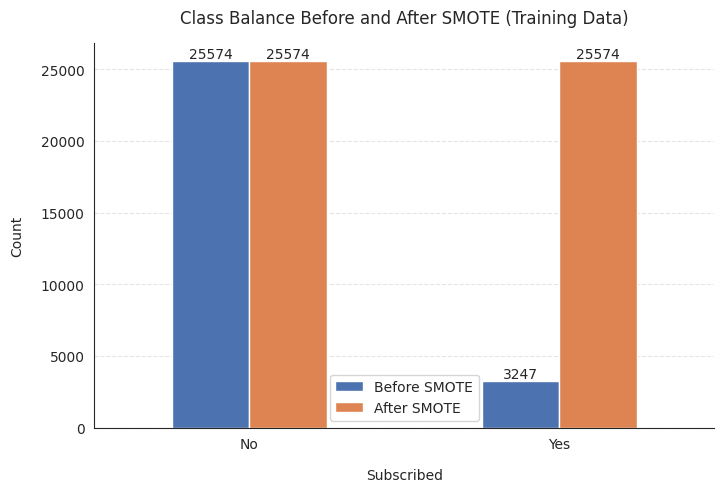

     Before SMOTE  After SMOTE
y                             
No          25574        25574
Yes          3247        25574


In [ ]:
demo_transformed = preprocessor.fit_transform(X_train)
X_res, y_res = SMOTE(random_state=42).fit_resample(demo_transformed, y_train)

balance_df = pd.DataFrame({
    'Before SMOTE': y_train.value_counts().sort_index(),
    'After SMOTE': pd.Series(y_res).value_counts().sort_index()
}).rename(index={0: 'No', 1: 'Yes'})

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
balance_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.title('Class Balance Before and After SMOTE (Training Data)', pad=14)
plt.xlabel('Subscribed', labelpad=12)
plt.ylabel('Count', labelpad=12)
plt.xticks(rotation=0)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('smote_class_balance.png', dpi=300, bbox_inches='tight')
plt.show()

print(balance_df)

## 7. Baseline training

Four models with default parameters. Each is evaluated on the validation set: classification report, confusion matrix, and stored metrics and ROC data for the comparison plots.

In [ ]:
models = {
    'lgbm': {'name': 'LightGBM',
             'model': LGBMClassifier(random_state=42, verbosity=-1)},
    'xgb':  {'name': 'XGBoost',
             'model': XGBClassifier(random_state=42, eval_metric='logloss')},
    'rfc':  {'name': 'Random Forest',
             'model': RandomForestClassifier(random_state=42)},
    'lgr':  {'name': 'Logistic Regression',
             'model': LogisticRegression(random_state=42, max_iter=2000)},
}

In [ ]:
def evaluate_model(fitted_pipeline, name, X_eval, y_eval, tag=''):
    """Report, confusion matrix and metric dictionary for one fitted pipeline."""
    y_pred = fitted_pipeline.predict(X_eval)
    y_proba = fitted_pipeline.predict_proba(X_eval)[:, 1]

    print('-' * 90)
    print(f'--> {name}{tag} <--')
    print('-' * 90)
    print(classification_report(y_eval, y_pred))

    cm = confusion_matrix(y_eval, y_pred)
    plt.subplots(figsize=(6, 5), dpi=100)
    labels = ['No', 'Yes']
    sns.heatmap(cm, annot=True, fmt='d', cbar=True, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label', labelpad=12)
    plt.ylabel('True Label', labelpad=12)
    plt.title(f'Confusion Matrix: {name}{tag}', pad=14)
    plt.savefig(f'confusion_{name}{tag}.png', dpi=300, bbox_inches='tight')
    plt.show()

    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    return {
        'name': name,
        'Accuracy': accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred),
        'Recall': recall_score(y_eval, y_pred),
        'F1-score': f1_score(y_eval, y_pred),
        'ROC-AUC': roc_auc_score(y_eval, y_proba),
        'fpr': fpr, 'tpr': tpr,
    }


def show_sample_predictions(fitted_pipeline, name, X_eval, y_eval, n=10):
    """Show a sample of predictions against true labels."""
    y_pred = fitted_pipeline.predict(X_eval)
    sample = pd.DataFrame({
        'True Label': y_eval.values,
        'Predicted Label': y_pred,
        'Correct': np.where(y_pred == y_eval.values, 'Yes', 'No')
    }).sample(n, random_state=42)
    print(f'Sample predictions by {name}:')
    print(sample.to_string(index=False), '\n')

------------------------------------------------------------------------------------------
--> LightGBM <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5482
           1       0.58      0.33      0.42       696

    accuracy                           0.90      6178
   macro avg       0.75      0.65      0.68      6178
weighted avg       0.88      0.90      0.89      6178



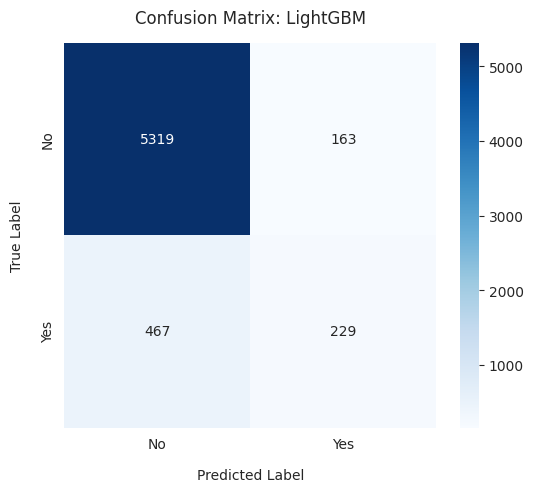

Sample predictions by LightGBM:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

------------------------------------------------------------------------------------------
--> XGBoost <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5482
           1       0.60      0.31      0.41       696

    accuracy                           0.90      6178
   macro avg       0.76      0.64      0.68      6178
weighted avg       0.88      0.90      0.88      6178



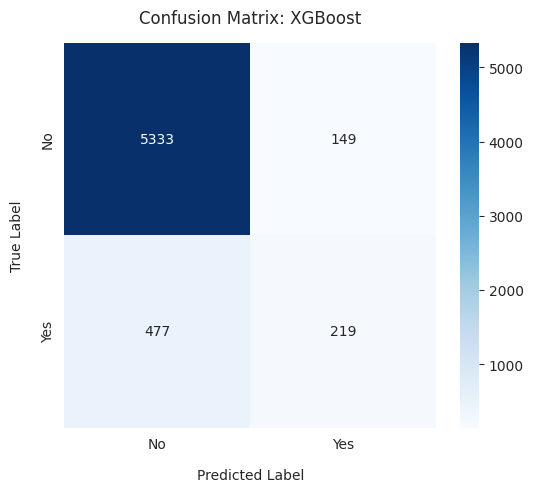

Sample predictions by XGBoost:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                0     Yes
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

------------------------------------------------------------------------------------------
--> Random Forest <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      5482
           1       0.50      0.35      0.41       696

    accuracy                           0.89      6178
   macro avg       0.71      0.65      0.68      6178
weighted avg       0.87      0.89      0.88      6178



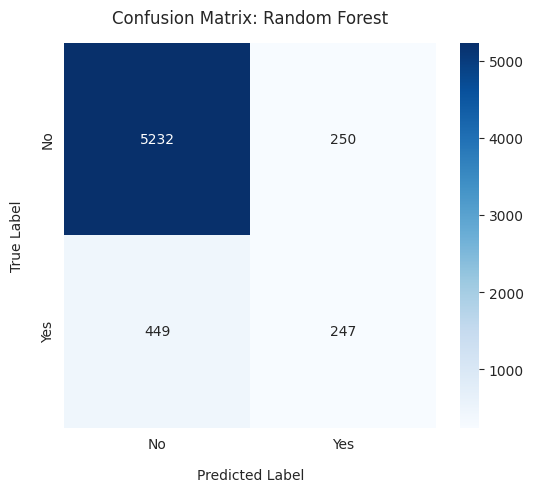

Sample predictions by Random Forest:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

------------------------------------------------------------------------------------------
--> Logistic Regression <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      5482
           1       0.33      0.62      0.43       696

    accuracy                           0.81      6178
   macro avg       0.64      0.73      0.66      6178
weighted avg       0.88      0.81      0.84      6178



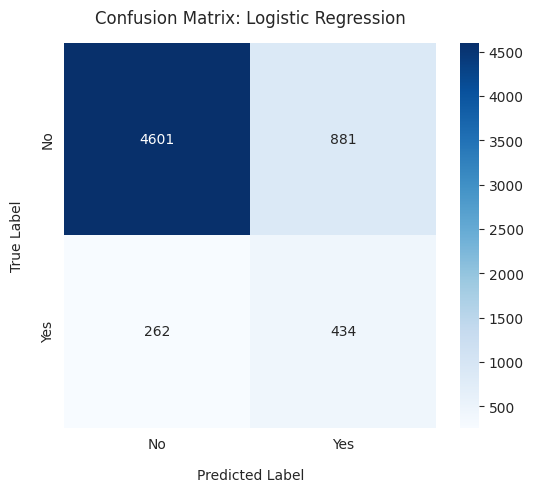

Sample predictions by Logistic Regression:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 



In [ ]:
baseline_results = {}

for abbr, spec in models.items():
    pipeline.set_params(model=spec['model'])
    pipeline.fit(X_train, y_train)
    baseline_results[abbr] = evaluate_model(pipeline, spec['name'], X_valid, y_valid)
    show_sample_predictions(pipeline, spec['name'], X_valid, y_valid)

## 8. Baseline model comparison

In [ ]:
def plot_metric_bar_chart(df_metrics, metric, tag=''):
    """Plots a single bar chart for a given metric across all models."""
    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    sns.barplot(data=df_metrics, x='name', y=metric, hue='name',
                palette='coolwarm', legend=False, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', label_type='edge')
    ax.set_ylim(0, 1.1)
    ax.set_yticks([])
    ax.set_title(f'{metric} Comparison Across Models{tag}')
    ax.set_xlabel('Model', labelpad=12)
    ax.set_ylabel('')
    sns.despine(top=True, right=True, left=True)
    plt.savefig(f'{metric}_comparison{tag}.png', dpi=300, bbox_inches='tight')
    plt.show()

def compare_metrics(results, tag=''):
    """Returns a DataFrame of metrics across all models."""
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
    df = pd.DataFrame([{k: r[k] for k in ['name'] + metric_cols}
                       for r in results.values()])
    display(df.set_index('name').round(3))
    return df

def plot_roc_curves(results, tag=''):
    """Combined ROC curves with AUC in the legend."""
    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Chance')
    for r in results.values():
        plt.plot(r['fpr'], r['tpr'], label=f"{r['name']} (AUC = {r['ROC-AUC']:.3f})")
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate', labelpad=12)
    plt.ylabel('True Positive Rate', labelpad=12)
    plt.title(f'ROC Curves for All Models{tag}')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(f'roc_curves{tag}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
baseline_df = compare_metrics(baseline_results, tag=' (Baseline)')

,Accuracy,Precision,Recall,F1-score,ROC-AUC
name,,,,,
LightGBM,0.898,0.584,0.329,0.421,0.788
XGBoost,0.899,0.595,0.315,0.412,0.773
Random Forest,0.887,0.497,0.355,0.414,0.774
Logistic Regression,0.815,0.330,0.624,0.432,0.778


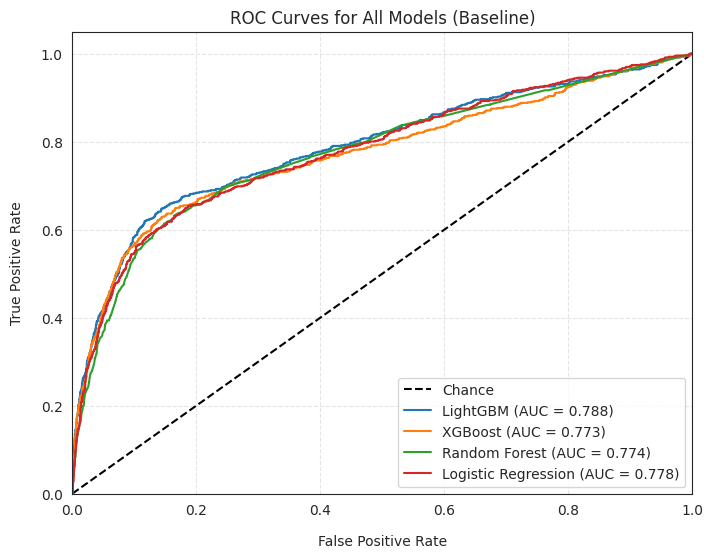

In [ ]:
plot_roc_curves(baseline_results, tag=' (Baseline)')

## 9. Hyperparameter tuning

RandomizedSearchCV with F1 scoring, 3-fold cross validation and 30 sampled combinations per model. Raise `N_ITER` and `CV_FOLDS` for a more thorough (and slower) search.

In [ ]:
N_ITER = 30
CV_FOLDS = 3

param_grids = {
    'lgbm': {
        'model__num_leaves': [15, 31, 63],
        'model__max_depth': [-1, 5, 8, 12],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__n_estimators': [200, 400, 800],
        'model__min_child_samples': [20, 50, 100],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
    },
    'xgb': {
        'model__n_estimators': [200, 400, 800],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
        'model__min_child_weight': [1, 5, 10],
        'model__gamma': [0, 0.1, 0.2],
    },
    'rfc': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [10, 20, 30, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2'],
    },
    'lgr': {
        'model__C': [0.01, 0.1, 1, 10, 50],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['saga'],
    },
}

Best CV F1 for LightGBM: 0.4952
Best parameters: {'model__subsample': 0.85, 'model__num_leaves': 63, 'model__n_estimators': 200, 'model__min_child_samples': 50, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}

------------------------------------------------------------------------------------------
--> LightGBM (Tuned) <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      5482
           1       0.45      0.55      0.49       696

    accuracy                           0.87      6178
   macro avg       0.70      0.73      0.71      6178
weighted avg       0.89      0.87      0.88      6178



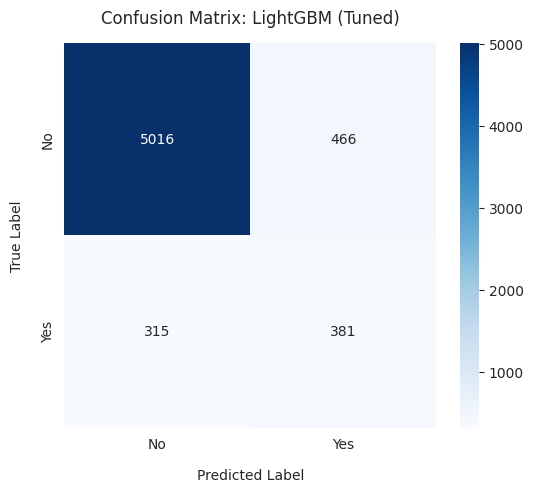

Sample predictions by LightGBM:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

Best CV F1 for XGBoost: 0.4883
Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 0.7}

------------------------------------------------------------------------------------------
--> XGBoost (Tuned) <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      5482
       

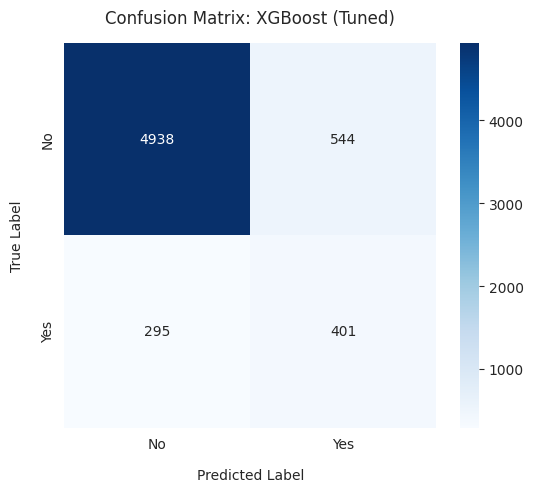

Sample predictions by XGBoost:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

Best CV F1 for Random Forest: 0.4907
Best parameters: {'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10}

------------------------------------------------------------------------------------------
--> Random Forest (Tuned) <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      5482
           1       0.43      0.56     

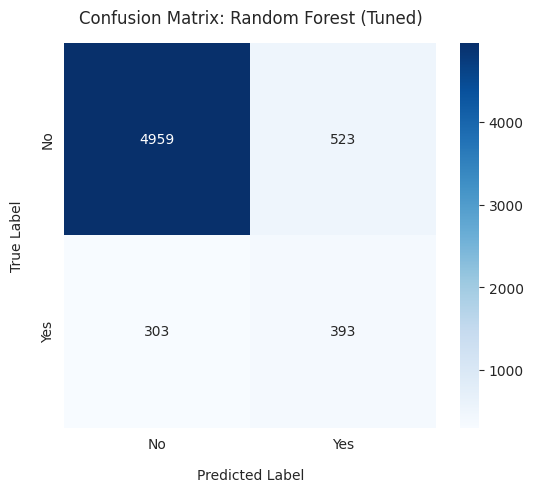

Sample predictions by Random Forest:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

Best CV F1 for Logistic Regression: 0.4290
Best parameters: {'model__solver': 'saga', 'model__penalty': 'l1', 'model__C': 0.1}

------------------------------------------------------------------------------------------
--> Logistic Regression (Tuned) <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      5482
           1       0.33      0.63      0.44       696

    accuracy                           0.82 

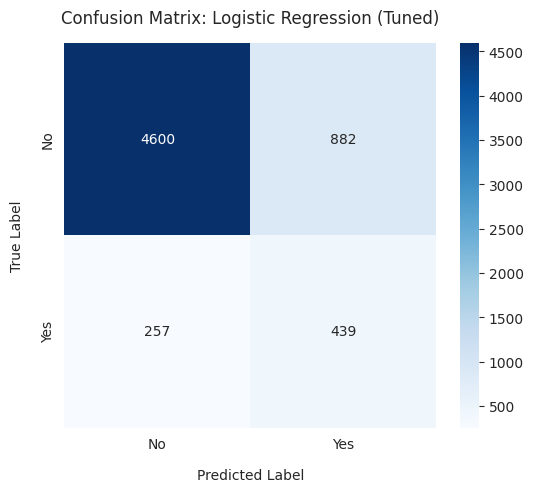

Sample predictions by Logistic Regression:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 



In [ ]:
tuned_results = {}
best_pipelines = {}
best_params = {}

for abbr, spec in models.items():
    pipeline.set_params(model=spec['model'])

    search = RandomizedSearchCV(
        pipeline, param_grids[abbr], n_iter=N_ITER, cv=CV_FOLDS,
        scoring='f1', n_jobs=-1, random_state=42)
    search.fit(X_train, y_train)

    best_pipelines[abbr] = search.best_estimator_
    best_params[abbr] = search.best_params_

    print(f"Best CV F1 for {spec['name']}: {search.best_score_:.4f}")
    print(f"Best parameters: {search.best_params_}\n")

    tuned_results[abbr] = evaluate_model(
        search.best_estimator_, spec['name'], X_valid, y_valid, tag=' (Tuned)')
    show_sample_predictions(search.best_estimator_, spec['name'], X_valid, y_valid)

## 10. Tuned model comparison

In [ ]:
tuned_df = compare_metrics(tuned_results, tag=' (Tuned)')

,Accuracy,Precision,Recall,F1-score,ROC-AUC
name,,,,,
LightGBM,0.874,0.450,0.547,0.494,0.783
XGBoost,0.864,0.424,0.576,0.489,0.782
Random Forest,0.866,0.429,0.565,0.488,0.784
Logistic Regression,0.816,0.332,0.631,0.435,0.778


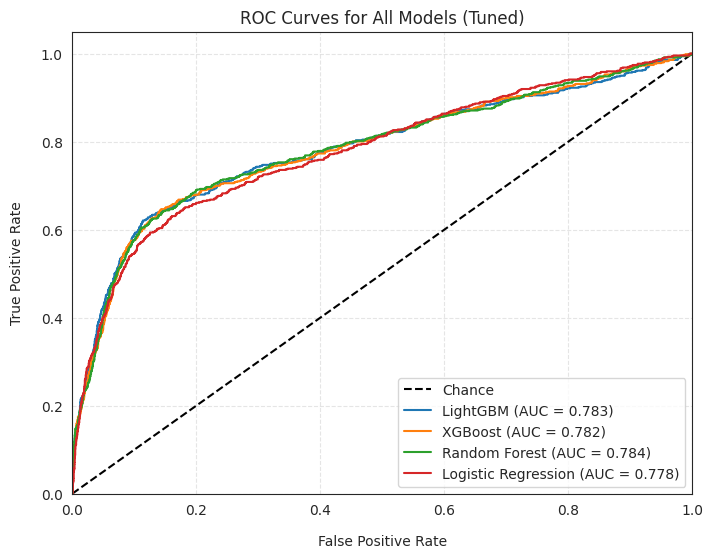

In [ ]:
plot_roc_curves(tuned_results, tag=' (Tuned)')

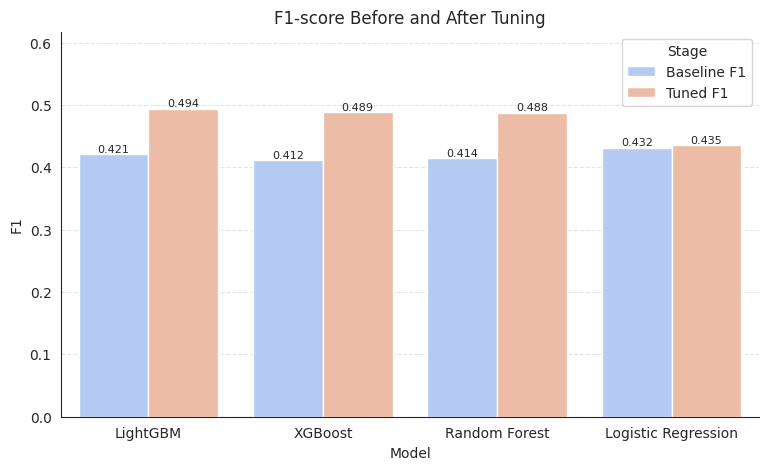

In [ ]:
# Baseline vs tuned F1, side by side
# Create a wide-format DataFrame comparing performance scores
compare = pd.DataFrame({
    'Model': [r['name'] for r in baseline_results.values()],
    'Baseline F1': [r['F1-score'] for r in baseline_results.values()],
    'Tuned F1': [tuned_results[k]['F1-score'] for k in baseline_results],
})

# Convert to long-format (melt) so Seaborn can group bars by 'Stage'
melted = compare.melt(id_vars='Model', var_name='Stage', value_name='F1')

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)
sns.barplot(data=melted, x='Model', y='F1', hue='Stage', palette='coolwarm', ax=ax)

# Automatically annotate each bar with its numerical value
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=8)

# Increase Y-limit to provide space for labels at the top of the bars
ax.set_ylim(0, max(melted['F1']) * 1.25)
ax.set_title('F1-score Before and After Tuning')
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('f1_before_after_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Final test set evaluation
 The test set has been held out until now
 to ensure the metrics reflect real-world performance on unseen data.

Best model on validation F1: LightGBM

------------------------------------------------------------------------------------------
--> LightGBM (Test Set) <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5481
           1       0.48      0.57      0.52       696

    accuracy                           0.88      6177
   macro avg       0.71      0.75      0.73      6177
weighted avg       0.89      0.88      0.89      6177



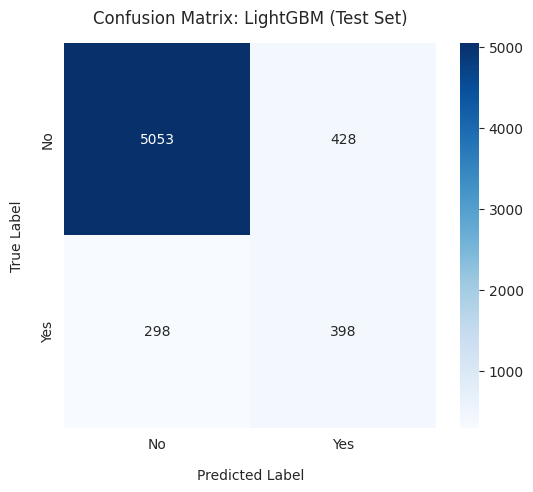

Test set F1:      0.5230
Test set ROC-AUC: 0.8108


In [ ]:

best_abbr = max(tuned_results, key=lambda k: tuned_results[k]['F1-score'])
best_name = models[best_abbr]['name']
print(f'Best model on validation F1: {best_name}\n')

test_result = evaluate_model(
    best_pipelines[best_abbr], best_name, X_test, y_test, tag=' (Test Set)')

print(f"Test set F1:      {test_result['F1-score']:.4f}")
print(f"Test set ROC-AUC: {test_result['ROC-AUC']:.4f}")

## 12. Feature importance

Tree models expose `feature_importances_`. Logistic regression uses absolute coefficient magnitudes on the scaled features, which ranks influence but hides direction; the sign of each coefficient tells me whether the feature pushes towards or away from subscription.

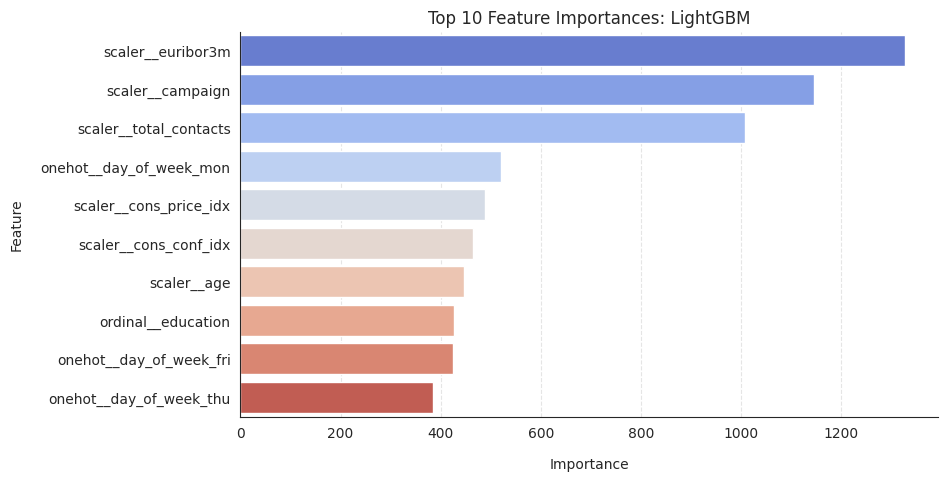

,feature,importance
0,scaler__euribor3m,1327
1,scaler__campaign,1146
2,scaler__total_contacts,1009
3,onehot__day_of_week_mon,521
4,scaler__cons_price_idx,489
5,scaler__cons_conf_idx,465
6,scaler__age,447
7,ordinal__education,426
8,onehot__day_of_week_fri,425
9,onehot__day_of_week_thu,385


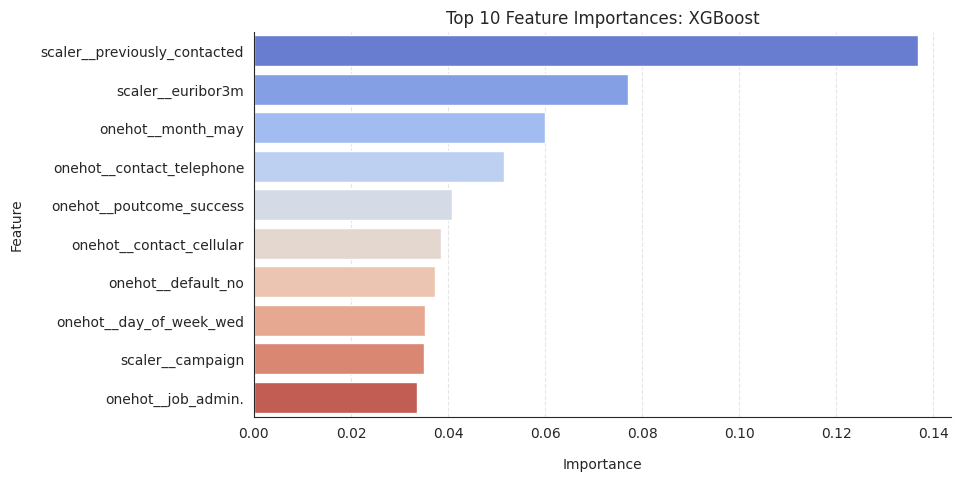

,feature,importance
0,scaler__previously_contacted,0.136885
1,scaler__euribor3m,0.077115
2,onehot__month_may,0.060043
3,onehot__contact_telephone,0.051477
4,onehot__poutcome_success,0.040874
5,onehot__contact_cellular,0.038622
6,onehot__default_no,0.037407
7,onehot__day_of_week_wed,0.035315
8,scaler__campaign,0.034975
9,onehot__job_admin.,0.033685


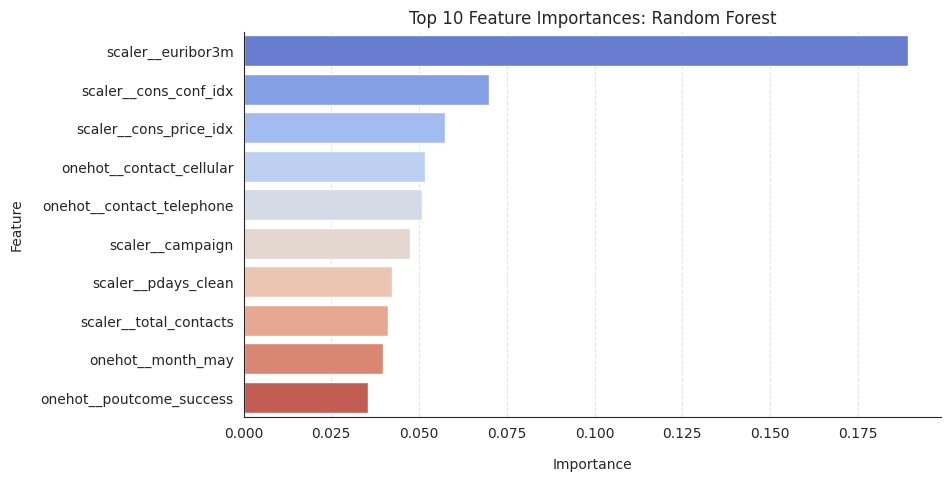

,feature,importance
0,scaler__euribor3m,0.189247
1,scaler__cons_conf_idx,0.069799
2,scaler__cons_price_idx,0.057440
3,onehot__contact_cellular,0.051604
4,onehot__contact_telephone,0.050866
5,scaler__campaign,0.047375
6,scaler__pdays_clean,0.042244
7,scaler__total_contacts,0.041247
8,onehot__month_may,0.039821
9,onehot__poutcome_success,0.035536


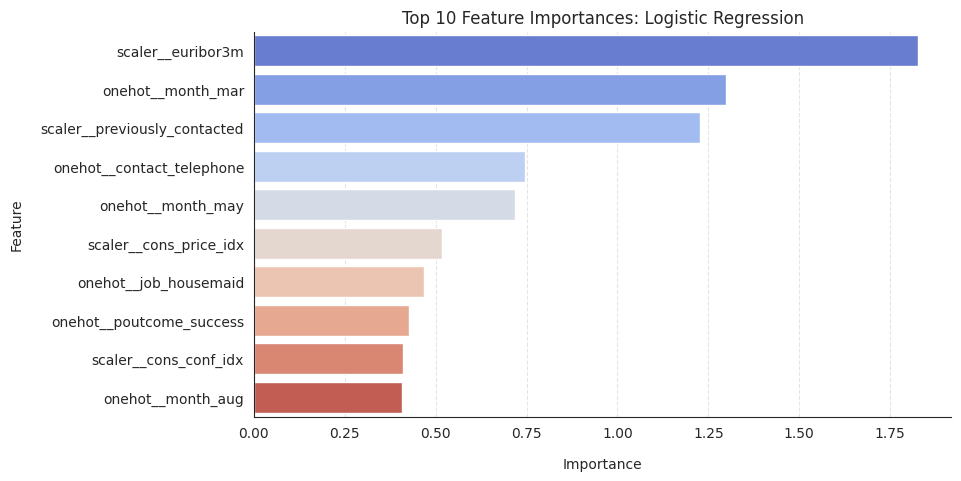

,feature,importance
0,scaler__euribor3m,1.827006
1,onehot__month_mar,1.297830
2,scaler__previously_contacted,1.227542
3,onehot__contact_telephone,0.746533
4,onehot__month_may,0.719381
5,scaler__cons_price_idx,0.517252
6,onehot__job_housemaid,0.467554
7,onehot__poutcome_success,0.426694
8,scaler__cons_conf_idx,0.409238
9,onehot__month_aug,0.406080


In [ ]:
def plot_feature_importance(fitted_pipeline, name, top_n=10):
    """Top-N importance chart for one tuned pipeline."""
    # 1. Extract the actual model and feature names from the fitted pipeline
    model = fitted_pipeline.named_steps['model']
    feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

    # 2. Extract importance values based on model type
    if hasattr(model, 'feature_importances_'):
        # For tree-based models (Random Forest, XGBoost, LightGBM)
        importance = model.feature_importances_
    else:
        # For Logistic Regression, use absolute coefficient values as importance
        importance = np.abs(model.coef_.flatten())

    # 3. Create a DataFrame to rank and filter the top N features
    df_imp = (pd.DataFrame({'feature': feature_names, 'importance': importance})
                .sort_values('importance', ascending=False)
                .head(top_n))

    # 4. Visualize the results using a bar chart
    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    sns.barplot(data=df_imp, x='importance', y='feature', hue='feature',
                palette='coolwarm', legend=False, ax=ax)
    ax.set_title(f'Top {top_n} Feature Importances: {name}')
    ax.set_xlabel('Importance', labelpad=12)
    ax.set_ylabel('Feature', labelpad=12)
    sns.despine(top=True, right=True)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.savefig(f'importance_{name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return df_imp

# Loop through all trained models to generate importance plots
for abbr, spec in models.items():
    imp_df = plot_feature_importance(best_pipelines[abbr], spec['name'])
    display(imp_df.reset_index(drop=True))

## 13. SHAP analysis

SHAP values are computed for every tuned model: TreeExplainer for the tree ensembles and LinearExplainer for logistic regression. Each beeswarm plot shows how features push individual predictions towards or away from subscription. Feature names are taken from each model's own fitted preprocessor rather than shared across models, so the labels stay correct even if encoders ever diverge. A 500-row sample keeps computation quick.

------------------------------------------------------------------------------------------
--> SHAP for LightGBM <--
------------------------------------------------------------------------------------------


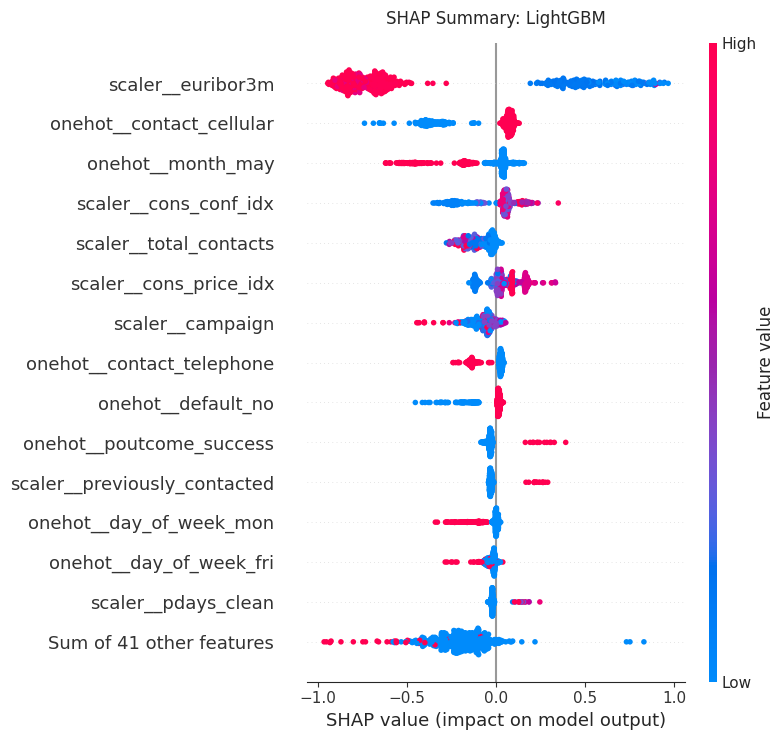



------------------------------------------------------------------------------------------
--> SHAP for XGBoost <--
------------------------------------------------------------------------------------------


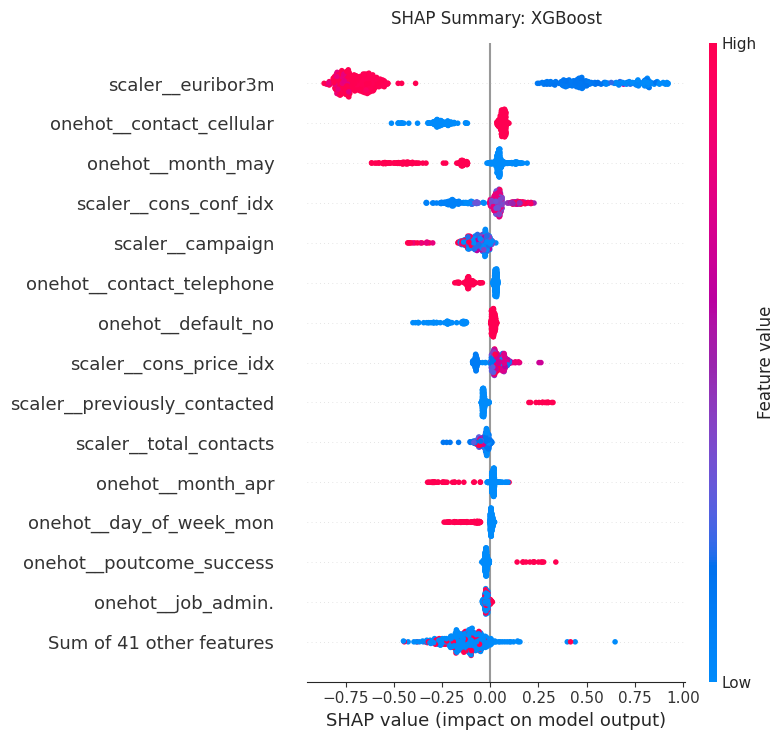



------------------------------------------------------------------------------------------
--> SHAP for Random Forest <--
------------------------------------------------------------------------------------------


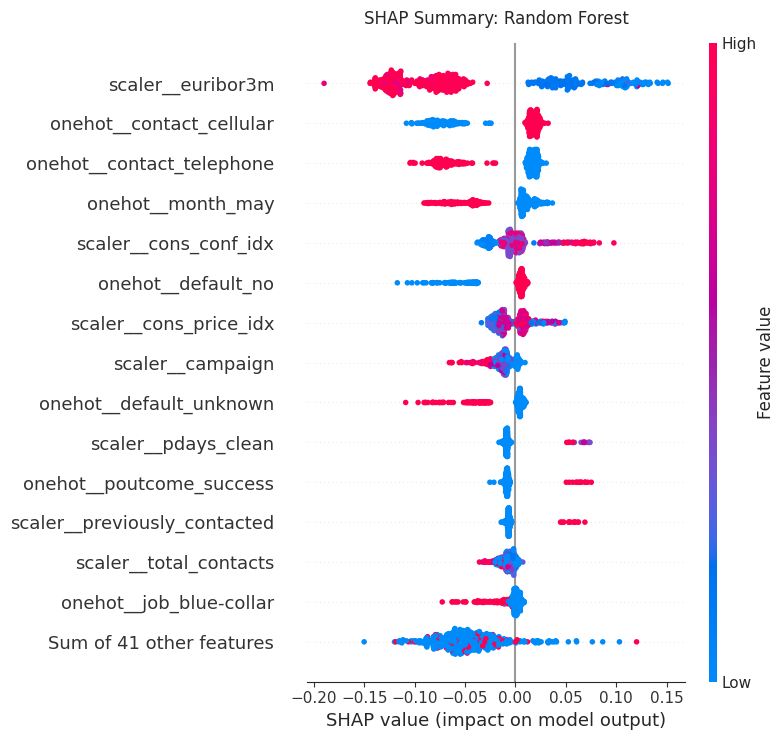



------------------------------------------------------------------------------------------
--> SHAP for Logistic Regression <--
------------------------------------------------------------------------------------------


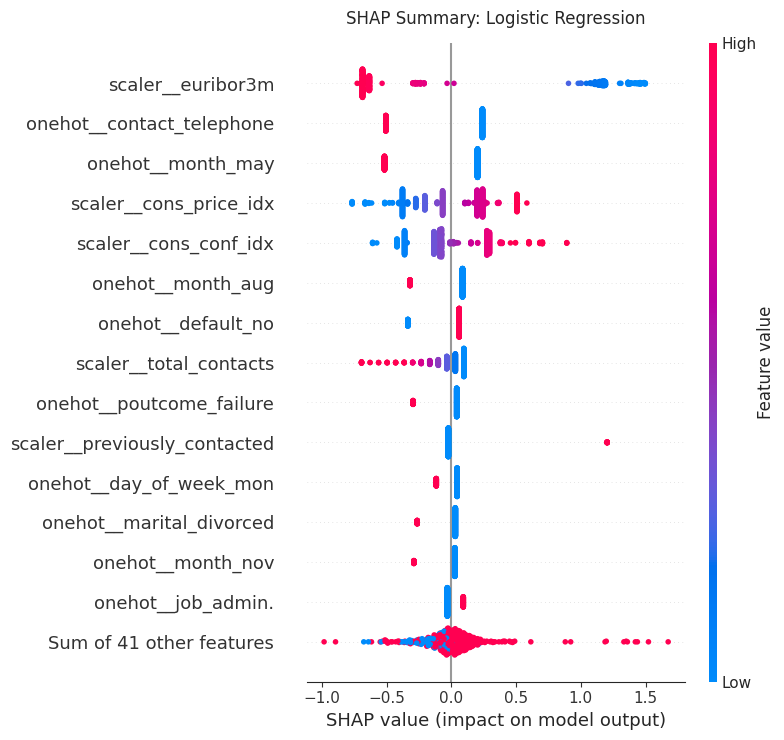

In [ ]:
SHAP_SAMPLE_SIZE = 500
shap_sample = X_valid.sample(min(SHAP_SAMPLE_SIZE, len(X_valid)),
                             random_state=42)


def shap_inputs(fitted_pipeline, X_raw):
    """Transformed sample and matching feature names for one pipeline."""
    pre = fitted_pipeline.named_steps['preprocessor']
    transformed = pre.transform(X_raw)
    if hasattr(transformed, 'toarray'):
        transformed = transformed.toarray()
    names = pre.get_feature_names_out()
    return pd.DataFrame(transformed, columns=names), names


shap_values_store = {}

for abbr, spec in models.items():
    fitted = best_pipelines[abbr]
    model = fitted.named_steps['model']
    X_shap, names = shap_inputs(fitted, shap_sample)

    print('-' * 90)
    print(f"--> SHAP for {spec['name']} <--")
    print('-' * 90)

    if abbr == 'lgr':
        explainer = shap.LinearExplainer(model, X_shap)
    else:
        explainer = shap.TreeExplainer(model)

    explanation = explainer(X_shap)
    values = explanation.values
    base_values = np.array(explanation.base_values)
    if values.ndim == 3:  # some tree explainers return one slice per class
        values = values[:, :, 1]
        base_values = base_values[:, 1] if base_values.ndim > 1 else base_values

    explanation = shap.Explanation(values=values, base_values=base_values,
                                   data=X_shap.values, feature_names=names)
    shap_values_store[abbr] = explanation

    plt.figure()
    shap.plots.beeswarm(explanation, max_display=15, show=False)
    plt.title(f"SHAP Summary: {spec['name']}", pad=14)
    plt.tight_layout()
    plt.savefig(f"shap_beeswarm_{abbr}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print('\n')

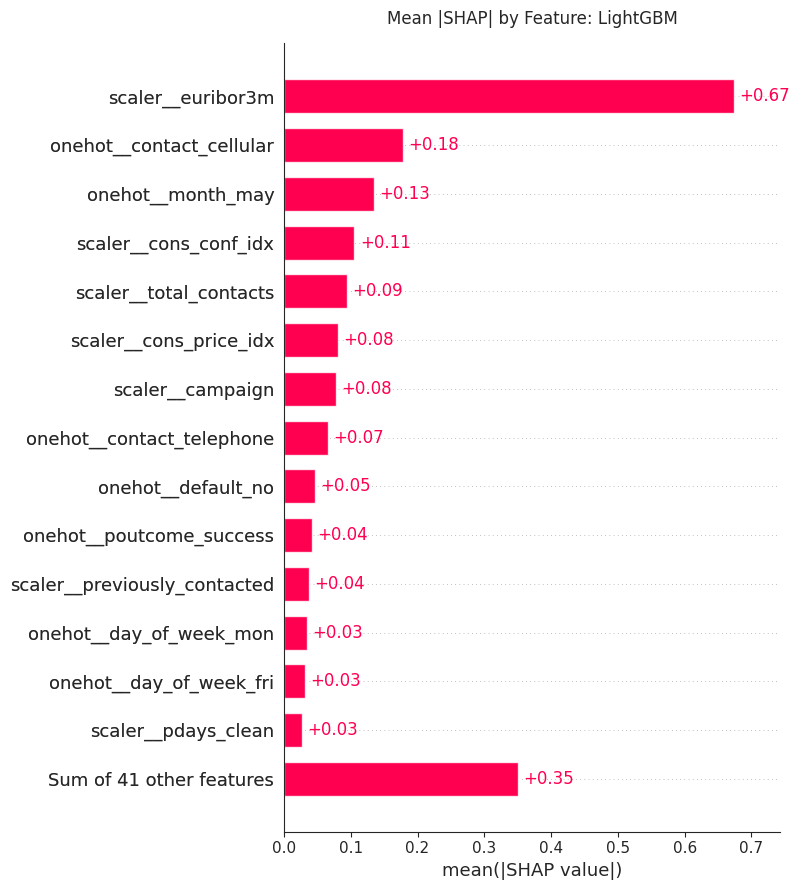

In [ ]:
# Mean absolute SHAP impact for the best model
shap.plots.bar(shap_values_store[best_abbr], max_display=15, show=False)
plt.title(f'Mean |SHAP| by Feature: {best_name}', pad=14)
plt.tight_layout()
plt.savefig('shap_bar_best_model.png', dpi=300, bbox_inches='tight')
plt.show()